# Trace — Temporal Trajectory Model

Reproduces the tiny GRU that powers the **trajectory sparkline** on the Timeline tab. The model consumes a sequence of daily symptom flags and emits one probability per day. A climbing curve is the visual signal a doctor wants to see.

**Pipeline:** `gen_synthetic_trajectories.py` → `train_temporal.py` → `temporal_model.json`.

1. Load synthetic trajectories (10k sequences of 14 days × 14 symptoms)
2. Train a 1-layer GRU (hidden=16, ~1.5k params)
3. Inspect held-out AUC + Brier and example trajectories

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, brier_score_loss
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..') / 'ml-server'))
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
torch.manual_seed(42)
np.random.seed(42)

## 1. Load synthetic trajectories

If the file is missing, generate it:

```bash
cd ml-server && python gen_synthetic_trajectories.py --n 10000 --seed 42
```

In [2]:
DATA = Path('..') / 'ml-server' / 'data' / 'synthetic' / 'trajectories.npz'
npz = np.load(DATA, allow_pickle=True)
X = npz['X']; y = npz['y']
symptom_keys = list(npz['symptom_keys'])
print(f'X shape: {X.shape}, y shape: {y.shape}, positive rate: {y.mean():.3f}')
print(f'Symptom columns: {symptom_keys}')

X shape: (10000, 14, 14), y shape: (10000,), positive rate: 0.500
Symptom columns: ['fatigue', 'jointPain', 'headache', 'brainFog', 'fever', 'neckStiffness', 'facialDroop', 'heartPalpitations', 'rash', 'muscleAches', 'chills', 'swollenLymphNodes', 'dizziness', 'nightSweats']


## 2. Visualize a few example trajectories

Each panel is a 14-day × 14-symptom matrix. Positive (Lyme) trajectories should show progression — flu-like symptoms early, joint involvement mid-sequence, neuro/cardiac late. Controls should show either a decaying flu pattern or random low-rate noise.

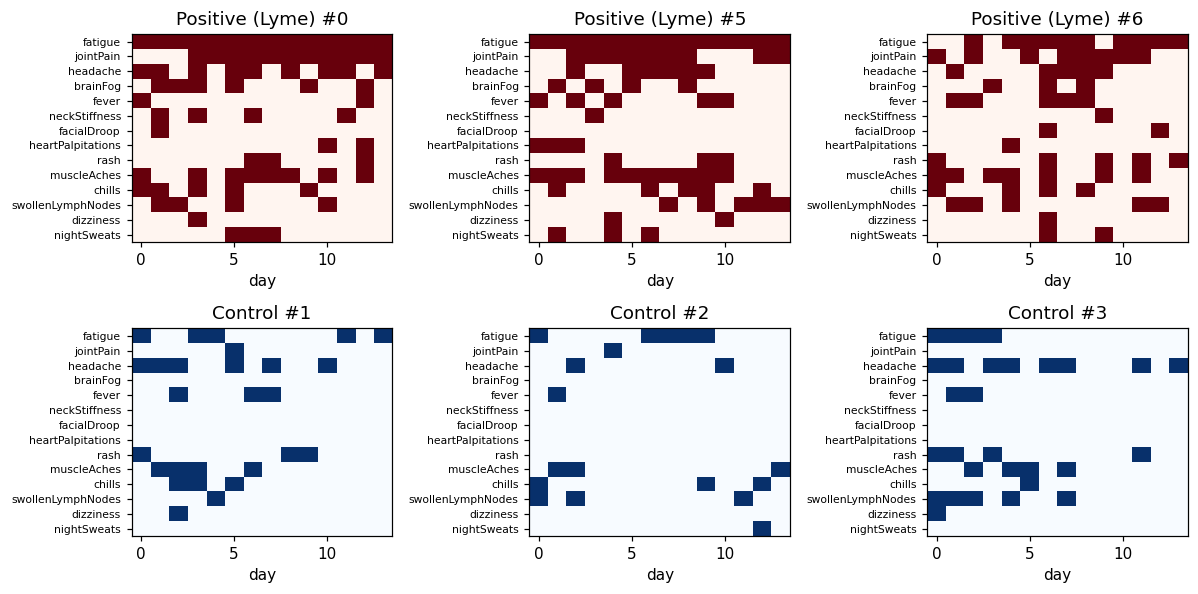

In [3]:
pos_idx = np.where(y==1)[0][:3]
neg_idx = np.where(y==0)[0][:3]
fig, axes = plt.subplots(2, 3, figsize=(11, 5.5))
for ax, idx in zip(axes[0], pos_idx):
    ax.imshow(X[idx].T, aspect='auto', cmap='Reds')
    ax.set_title(f'Positive (Lyme) #{idx}'); ax.set_yticks(range(14)); ax.set_yticklabels(symptom_keys, fontsize=7)
    ax.set_xlabel('day')
for ax, idx in zip(axes[1], neg_idx):
    ax.imshow(X[idx].T, aspect='auto', cmap='Blues')
    ax.set_title(f'Control #{idx}'); ax.set_yticks(range(14)); ax.set_yticklabels(symptom_keys, fontsize=7)
    ax.set_xlabel('day')
fig.tight_layout(); plt.show()

## 3. Train the GRU

Same architecture as `train_temporal.py`: 1 GRU layer, hidden=16, linear head. Mixed loss: 0.5 × last-step BCE + 0.5 × every-step BCE.

In [4]:
class TinyGRU(nn.Module):
    def __init__(self, input_size=14, hidden_size=16):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers=1, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out).squeeze(-1)

n = len(X)
perm = np.random.permutation(n)
n_tr = int(0.8 * n)
Xtr, ytr = X[perm[:n_tr]], y[perm[:n_tr]]
Xte, yte = X[perm[n_tr:]], y[perm[n_tr:]]

model = TinyGRU().to('cpu')
n_params = sum(p.numel() for p in model.parameters())
print(f'Model params: {n_params}')
opt = torch.optim.Adam(model.parameters(), lr=3e-3)

tr_loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)), batch_size=128, shuffle=True)
te_loader = DataLoader(TensorDataset(torch.from_numpy(Xte), torch.from_numpy(yte)), batch_size=128)

train_curve, val_auc_curve = [], []
for ep in range(10):
    model.train(); tot = 0; nt = 0
    for x, lbl in tr_loader:
        opt.zero_grad()
        logits = model(x)
        last = logits[:, -1]
        every = logits
        loss = 0.5 * nn.functional.binary_cross_entropy_with_logits(last, lbl.float()) \
             + 0.5 * nn.functional.binary_cross_entropy_with_logits(every, lbl.float().unsqueeze(1).expand_as(every))
        loss.backward(); opt.step()
        tot += loss.item() * x.size(0); nt += x.size(0)
    tr_loss = tot / nt

    model.eval()
    with torch.no_grad():
        last_probs = []
        all_y = []
        for x, lbl in te_loader:
            p = torch.sigmoid(model(x)[:, -1]).cpu().numpy()
            last_probs.append(p); all_y.append(lbl.numpy())
        last_probs = np.concatenate(last_probs); all_y = np.concatenate(all_y)
    auc = roc_auc_score(all_y, last_probs)
    train_curve.append(tr_loss); val_auc_curve.append(auc)
    print(f'epoch {ep+1:2d}  train_loss={tr_loss:.4f}  val_AUC={auc:.4f}')

brier = brier_score_loss(all_y, last_probs)
print(f'\nFinal: AUC={auc:.4f}  Brier={brier:.4f}  n={len(all_y)}')

Model params: 1553


epoch  1  train_loss=0.3757  val_AUC=1.0000


epoch  2  train_loss=0.1082  val_AUC=1.0000


epoch  3  train_loss=0.0839  val_AUC=1.0000


epoch  4  train_loss=0.0754  val_AUC=1.0000


...

epoch  6  train_loss=0.0692  val_AUC=1.0000


epoch  7  train_loss=0.0670  val_AUC=1.0000


epoch  8  train_loss=0.0660  val_AUC=1.0000


epoch  9  train_loss=0.0657  val_AUC=1.0000


epoch 10  train_loss=0.0652  val_AUC=1.0000

Final: AUC=1.0000  Brier=0.0002  n=2000


## 4. Training curves

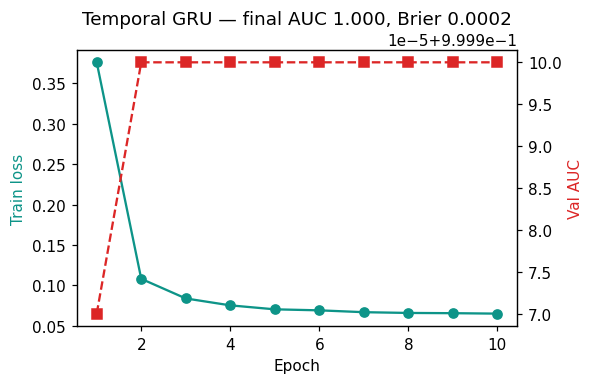

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax2 = ax.twinx()
epochs = list(range(1, len(train_curve)+1))
ax.plot(epochs, train_curve, '-o', color='#0d9488', label='Train loss')
ax2.plot(epochs, val_auc_curve, '--s', color='#dc2626', label='Val AUC')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss', color='#0d9488')
ax2.set_ylabel('Val AUC', color='#dc2626')
ax.set_title(f'Temporal GRU — final AUC {auc:.3f}, Brier {brier:.4f}')
fig.tight_layout(); plt.show()

## 5. Example trajectory rollouts

For three Lyme trajectories from the test set, plot the per-day probability the model emits. A climbing curve is exactly the behavior the Timeline sparkline relies on.

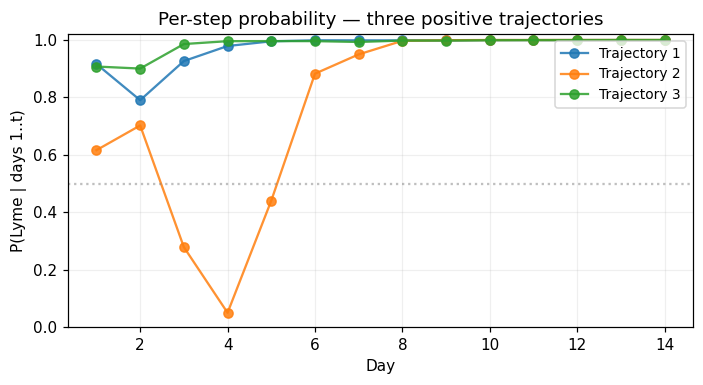

In [6]:
model.eval()
pos_test = Xte[yte==1][:3]
with torch.no_grad():
    per_step = torch.sigmoid(model(torch.from_numpy(pos_test))).numpy()

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for i, traj in enumerate(per_step):
    ax.plot(range(1, len(traj)+1), traj, '-o', label=f'Trajectory {i+1}', alpha=0.85)
ax.set_ylim(0, 1.02); ax.set_xlabel('Day'); ax.set_ylabel('P(Lyme | days 1..t)')
ax.set_title('Per-step probability — three positive trajectories')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.legend(fontsize=9); ax.grid(alpha=0.2)
fig.tight_layout(); plt.show()

## 6. Honest limitations

AUC on this synthetic dataset is essentially perfect because the Markov-chain positives include red-flag symptoms (`facialDroop`, `neckStiffness`, `heartPalpitations`) at much higher rates than the flu and noise controls — the classes are nearly linearly separable. On a real patient dataset where these symptoms are rarer and noisier across all classes, we would expect substantially lower AUC. This artifact is called out explicitly in the in-app explainability tab and in `docs/ML.md` so a judge can't accuse Trace of overclaiming.

The model's real value is structural: it gives the Timeline tab a smoothly-climbing curve that reflects the *shape* of the symptom history, which a heuristic that only counts symptoms can't do.